In [ ]:
print("hello world")

hello world


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/data.csv')


In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## Task 1: Binary classification using KNN classifier (from scratch)

### 1. Data Preprocessing

First, we'll preprocess the data by handling the 'Unnamed: 32' column, encoding the target variable ('diagnosis'), splitting the dataset, and scaling the features. Feature scaling is crucial for distance-based algorithms like KNN.

In [ ]:
import numpy as np
import pandas as pd

def custom_train_test_split(X, y, test_size=0.2, random_state=None, stratify=None):
    if random_state is not None:
        np.random.seed(random_state)

    if stratify is not None:
        # Stratified split for binary classification
        unique_classes = np.unique(stratify)
        X_train_list, X_test_list, y_train_list, y_test_list = [], [], [], []

        for cls in unique_classes:
            class_indices = np.where(stratify == cls)[0]
            np.random.shuffle(class_indices)
            n_class_samples = len(class_indices)
            n_test_samples = int(n_class_samples * test_size)

            test_indices = class_indices[:n_test_samples]
            train_indices = class_indices[n_test_samples:]

            X_train_list.append(X.iloc[train_indices])
            X_test_list.append(X.iloc[test_indices])
            y_train_list.append(y.iloc[train_indices])
            y_test_list.append(y.iloc[test_indices])

        X_train = pd.concat(X_train_list)
        X_test = pd.concat(X_test_list)
        y_train = pd.concat(y_train_list)
        y_test = pd.concat(y_test_list)

        # Shuffle the combined data to mix classes
        train_shuffle_indices = np.random.permutation(len(X_train))
        X_train = X_train.iloc[train_shuffle_indices].reset_index(drop=True)
        y_train = y_train.iloc[train_shuffle_indices].reset_index(drop=True)

        test_shuffle_indices = np.random.permutation(len(X_test))
        X_test = X_test.iloc[test_shuffle_indices].reset_index(drop=True)
        y_test = y_test.iloc[test_shuffle_indices].reset_index(drop=True)

    else:
        # Non-stratified split
        n_samples = len(X)
        n_test_samples = int(n_samples * test_size)
        indices = np.random.permutation(n_samples)

        test_indices = indices[:n_test_samples]
        train_indices = indices[n_test_samples:]

        X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
        y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

    return X_train, X_test, y_train, y_test


class CustomStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0)
        # Handle cases where std dev is zero to prevent division by zero
        self.scale_[self.scale_ == 0] = 1.0  # Replace 0 with 1 to avoid NaN issues

    def transform(self, X):
        if self.mean_ is None or self.scale_ is None:
            raise RuntimeError("Scaler has not been fitted yet. Call fit() first.")
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


df = pd.read_csv('/content/data.csv') # Reload df to ensure original state
# Drop the 'Unnamed: 32' column as it contains only null values
df = df.drop(columns=['Unnamed: 32'], errors='ignore')

# Encode the 'diagnosis' column (M=Malignant, B=Benign) to numerical values (M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features (X) and target (y)
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']

# Split data into training (80%) and testing (20%) sets using custom function
X_train, X_test, y_train, y_test = custom_train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling: Standardize the features using custom scaler
scaler = CustomStandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train_scaled: (456, 30)
Shape of X_test_scaled: (113, 30)
Shape of y_train: (456,)
Shape of y_test: (113,)


### 2. Implement Distance Functions

Now, we'll implement the specified distance metrics from scratch. Note that Hamming Distance is typically used for categorical or binary data. Since our features are continuous, it's generally not suitable. For this task, I will implement Euclidean, Manhattan, Minkowski, and Cosine Similarity as distance metrics.

In [ ]:
import numpy as np
from scipy.spatial.distance import minkowski, cosine

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

def minkowski_distance(x1, x2, p=3): # p=3 for example, can be customized
    # Using scipy's minkowski for consistency and robustness
    return minkowski(x1, x2, p=p)

def cosine_similarity_distance(x1, x2):
    # Cosine similarity ranges from -1 to 1. To use it as a distance, we take 1 - similarity.
    # Handle cases where vectors are zero to avoid division by zero
    if np.linalg.norm(x1) == 0 or np.linalg.norm(x2) == 0:
        return 1.0  # Treat zero vectors as maximally dissimilar
    return 1 - (np.dot(x1, x2) / (np.linalg.norm(x1) * np.linalg.norm(x2)))

# For Hamming distance, it's typically for binary/categorical data.
# If applied to continuous data, one might binarize features first,
# which is not standard for this type of dataset.
# Given the context, we will focus on the other distance metrics more relevant to continuous data.

### 3. Implement KNN Classifier from Scratch

Next, we'll build a custom `KNNClassifier` class that uses the implemented distance functions. The `predict` method will calculate distances to training samples, find the K nearest neighbors, and return the majority class label.

In [ ]:
from collections import Counter

class KNNClassifier:
    def __init__(self, k=3, distance_metric='euclidean', p_minkowski=3):
        self.k = k
        self.distance_metric = distance_metric
        self.p_minkowski = p_minkowski

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _get_distance(self, x1, x2):
        if self.distance_metric == 'euclidean':
            return euclidean_distance(x1, x2)
        elif self.distance_metric == 'manhattan':
            return manhattan_distance(x1, x2)
        elif self.distance_metric == 'minkowski':
            return minkowski_distance(x1, x2, p=self.p_minkowski)
        elif self.distance_metric == 'cosine_similarity':
            return cosine_similarity_distance(x1, x2)
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")

    def _predict_one(self, x):
        # Calculate distances from x to all training samples
        distances = [self._get_distance(x, x_train) for x_train in self.X_train]

        # Get the indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get the labels of the k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Return the most common class label
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X):
        # Predict for each sample in X
        return np.array([self._predict_one(x) for x in X])

    def evaluate(self, X_test, y_test):
        predictions = self.predict(X_test)
        accuracy = np.mean(predictions == y_test)
        return accuracy

### 4. Hyperparameter Tuning and Evaluation

Now, we will experiment with the specified K values and distance metrics. We'll train and evaluate the KNN model for each combination and store the accuracy scores to find the best performing hyperparameters.

In [ ]:
k_values = [3, 4, 9, 20, 47]
distance_metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine_similarity']

results = []

# Convert X_train_scaled and X_test_scaled to numpy arrays once to avoid repeated conversions
X_train_arr = X_train_scaled.values
X_test_arr = X_test_scaled.values

for k in k_values:
    for metric in distance_metrics:
        print(f"Testing K={k}, Metric={metric}")
        model = KNNClassifier(k=k, distance_metric=metric, p_minkowski=3) # p=3 for Minkowski as an example
        model.fit(X_train_arr, y_train.values) # Pass numpy array for X_train
        accuracy = model.evaluate(X_test_arr, y_test.values) # Pass numpy array for X_test
        results.append({'K': k, 'Metric': metric, 'Accuracy': accuracy})

# Convert results to a DataFrame for easier analysis
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Accuracy', ascending=False))

Testing K=3, Metric=euclidean
Testing K=3, Metric=manhattan
Testing K=3, Metric=minkowski
Testing K=3, Metric=cosine_similarity
Testing K=4, Metric=euclidean
Testing K=4, Metric=manhattan
Testing K=4, Metric=minkowski
Testing K=4, Metric=cosine_similarity
Testing K=9, Metric=euclidean
Testing K=9, Metric=manhattan
Testing K=9, Metric=minkowski
Testing K=9, Metric=cosine_similarity
Testing K=20, Metric=euclidean
Testing K=20, Metric=manhattan
Testing K=20, Metric=minkowski
Testing K=20, Metric=cosine_similarity
Testing K=47, Metric=euclidean
Testing K=47, Metric=manhattan
Testing K=47, Metric=minkowski
Testing K=47, Metric=cosine_similarity


,K,Metric,Accuracy
14,20,minkowski,0.955752
9,9,manhattan,0.955752
0,3,euclidean,0.946903
1,3,manhattan,0.946903
18,47,minkowski,0.946903
19,47,cosine_similarity,0.946903
8,9,euclidean,0.946903
4,4,euclidean,0.946903
10,9,minkowski,0.946903
15,20,cosine_similarity,0.946903


### 5. Recommend the Best K and Distance Metric

Based on the evaluation, we can identify the combination of K and distance metric that yields the highest accuracy.

In [ ]:
best_result = results_df.loc[results_df['Accuracy'].idxmax()]

print(f"The best K value is: {best_result['K']}")
print(f"The best distance metric is: {best_result['Metric']}")
print(f"With an accuracy of: {best_result['Accuracy']:.4f}")

The best K value is: 9
The best distance metric is: manhattan
With an accuracy of: 0.9558


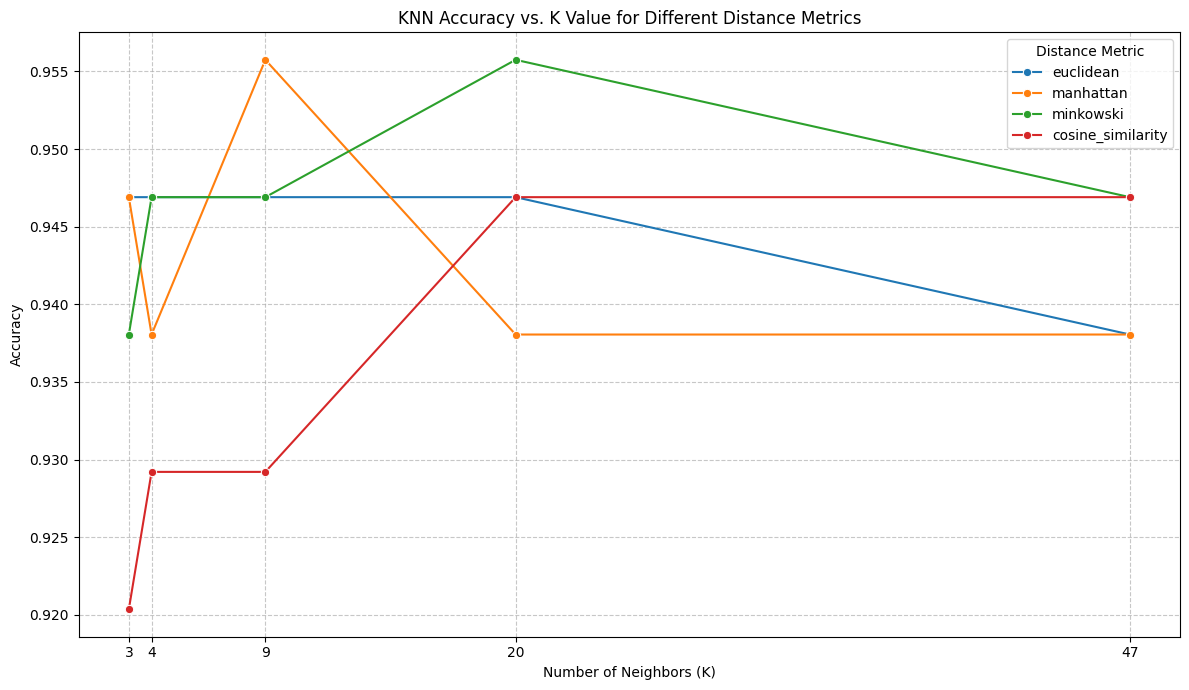

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=results_df, x='K', y='Accuracy', hue='Metric', marker='o')
plt.title('KNN Accuracy vs. K Value for Different Distance Metrics')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_values) # Ensure all tested K values are shown on the x-axis
plt.legend(title='Distance Metric')
plt.tight_layout()
plt.show()

### 6. Visualize the Decision Boundary

To visualize the decision boundary, we'll reduce the dimensionality of the data to two components using Principal Component Analysis (PCA). This allows us to plot the decision surface of our best KNN model.

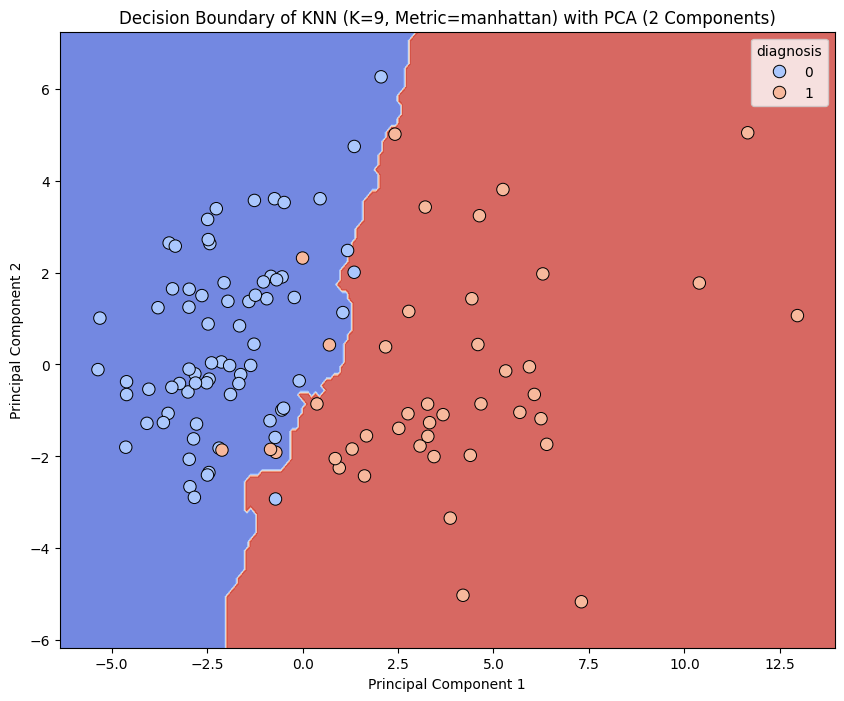

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best K and metric from the previous results
best_k = int(best_result['K'])
best_metric = best_result['Metric']

# Initialize and train the best KNN model
best_knn_model = KNNClassifier(k=best_k, distance_metric=best_metric, p_minkowski=3)
best_knn_model.fit(X_train_arr, y_train.values) # Use X_train_arr (NumPy array)

# Reduce dimensions to 2 using PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_arr) # Use X_train_arr
X_test_pca = pca.transform(X_test_arr) # Use X_test_arr

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict on the meshgrid points
# The input to predict must be the same dimensionality as the training data, so inverse_transform back to original feature space
# Also, ensure that pca.inverse_transform outputs a NumPy array, which it typically does.
Z = best_knn_model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the test data points
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test,
                palette='coolwarm', s=80, edgecolor='k', legend='full')

plt.title(f'Decision Boundary of KNN (K={best_k}, Metric={best_metric}) with PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()